# Assignment 1: Classification
# Telecom Churn

## 184.702 Machine Learning (VU 3,0) 2021W

### Group 11
Member: **András Bonifác Kónya** (Student ID: 01502933), **Branimir Raguž** (Student ID: 12123474), **Thummanoon Kunanuntakij** (Student ID: 12122522)

In [109]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import iqr
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, MaxAbsScaler
from sklearn.feature_selection import VarianceThreshold
from pprint import pprint
import warnings

## 1. Setup

In [122]:
RANDOM_SEED = 1234

In [123]:
def plot_params_accuracy(accuracy, xticks, height=10, width=10):
    fig, ax = plt.subplots(1, 1)
    fig.set_figheight(height)
    fig.set_figwidth(width)
    plt.sca(ax)
    plt.xticks(range(len(accuracy)), xticks)
    ax.plot(range(len(accuracy)), accuracy)
    fig.show()

## 2. Data Loading

In [124]:
if os.getcwd().split('/')[1] == 'kaggle':
    data_df = pd.read_csv('/kaggle/input/telecom-churn-datasets/churn-bigml-80.csv')
    test_df = pd.read_csv('/kaggle/input/telecom-churn-datasets/churn-bigml-20.csv')
else:
    data_df = pd.read_csv('../data/telecom_churn/churn-bigml-80.csv')
    test_df = pd.read_csv('../data/telecom_churn/churn-bigml-20.csv')

## 3. Overview of the Data

The goal of this dataset is to predict if a given customer will churn from a telecom subscription.
This dataset had 18 parameters. With 2665 observations for the training set and about 17% of the target varaibles are positive.

In [125]:
data_df.info()
data_df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

False    2278
True      388
Name: Churn, dtype: int64

## 3. Data Encoding

We determined that it would be much easier if we encode some column at this stage. So we can avoid repeatedly encode our data at during the model training. And because our encoding, unlike other process like scaling, doesn't provide any extra information to the model we can do it with both training and testing data.

First we rename the column name to make it consistent.

In [126]:
def rename_column(df):
    column_rename_mapper = {}
    for col in df.columns:
        column_rename_mapper[col] = col.replace(' ', '_').lower()
    df = df.rename(columns=column_rename_mapper)
    return df

Then, we encode the 'Yes' / 'No' as a binary column as it is more consistent with other numeric columns.

In [127]:
def encode_binary_columns(df, columns):
    for col in columns:
        df[col] = df[col].map(lambda value: 1 if value == 'Yes' else 0)
    return df

We use `drop_first=True` so that the function encode to a 1 less number of columns. This is too avoid multicollinearity.

In [128]:
def encode_categorical_columns(df, columns):
    for col in columns:
        df = pd.concat([df.drop(columns=[col]), pd.get_dummies(df[col], prefix=col, prefix_sep='_', drop_first=True)], axis=1)
    return df

In [129]:
def encoding_preprocess(df, boolean_columns, categorical_columns, drop_columns):
    df = encode_binary_columns(rename_column(df), boolean_columns)
    df = encode_categorical_columns(df, categorical_columns)
    df = df.drop(columns=drop_columns)
    return df

Here, we decide to drop `state` becuase if we encode them, it would add too many insignificance columns to our data.

In [130]:
data_df = encoding_preprocess(
    data_df,
    boolean_columns=['international_plan', 'voice_mail_plan'],
    categorical_columns=['area_code'],
    drop_columns=['state']
)
test_df = encoding_preprocess(
    test_df,
    boolean_columns=['international_plan', 'voice_mail_plan'],
    categorical_columns=['area_code'],
    drop_columns=['state']
)

In [131]:
data_df.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn,area_code_415,area_code_510
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,1,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,0,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1,0


## 4. Train / Test Data 
The data have already provide us with the modelling data and testing data. So we just split the modelling data for training and validation set.

In [236]:
X_model = data_df.drop(columns=['churn'])
y_model = data_df['churn']

X_train, X_val, y_train, y_val = train_test_split(X_model, y_model, test_size=0.2, random_state=RANDOM_SEED)

X_test = test_df.drop(columns=['churn'])
y_test = test_df['churn']


Our training data

In [133]:
X_train.describe()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,area_code_415,area_code_510
count,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000
mean,100.529550,0.102251,0.274859,7.962008,178.769559,100.346623,30.391341,199.396811,100.091463,16.948968,201.463837,100.098968,9.065957,10.224156,4.474203,2.761088,1.574109,0.500938,0.244371
std,39.378246,0.303050,0.446548,13.509472,54.644518,19.827184,9.289536,51.153421,20.191588,4.348064,49.874251,19.579701,2.244335,2.784438,2.482561,0.751746,1.308258,0.500116,0.429815
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,0.000000,0.000000,142.500000,88.000000,24.230000,163.475000,87.000000,13.897500,167.800000,87.000000,7.550000,8.400000,3.000000,2.270000,1.000000,0.000000,0.000000
50%,100.000000,0.000000,0.000000,0.000000,179.250000,101.000000,30.470000,200.100000,100.000000,17.010000,201.200000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000,1.000000,0.000000
75%,127.000000,0.000000,1.000000,19.000000,214.950000,114.000000,36.540000,233.050000,114.000000,19.812500,235.225000,113.000000,10.582500,12.100000,6.000000,3.270000,2.000000,1.000000,0.000000
max,225.000000,1.000000,1.000000,50.000000,350.800000,160.000000,59.640000,363.700000,170.000000,30.910000,381.900000,166.000000,17.190000,20.000000,20.000000,5.400000,9.000000,1.000000,1.000000


In [134]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2132 entries, 2200 to 723
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account_length          2132 non-null   int64  
 1   international_plan      2132 non-null   int64  
 2   voice_mail_plan         2132 non-null   int64  
 3   number_vmail_messages   2132 non-null   int64  
 4   total_day_minutes       2132 non-null   float64
 5   total_day_calls         2132 non-null   int64  
 6   total_day_charge        2132 non-null   float64
 7   total_eve_minutes       2132 non-null   float64
 8   total_eve_calls         2132 non-null   int64  
 9   total_eve_charge        2132 non-null   float64
 10  total_night_minutes     2132 non-null   float64
 11  total_night_calls       2132 non-null   int64  
 12  total_night_charge      2132 non-null   float64
 13  total_intl_minutes      2132 non-null   float64
 14  total_intl_calls        2132 non-null 

In [135]:
y_train.value_counts()

False    1820
True      312
Name: churn, dtype: int64

## 5. Data Preprocessing

### 5.1 Missing values
We could see that there are no N/A in our original dataset

In [136]:
X_model.isna().sum()

account_length            0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes       0
total_night_calls         0
total_night_charge        0
total_intl_minutes        0
total_intl_calls          0
total_intl_charge         0
customer_service_calls    0
area_code_415             0
area_code_510             0
dtype: int64

### 5.2 Outlier

From the histogram below (5.3), we could see that there are no outlier in the data.

### 5.3 Feature Scaling

The scale of each variables are differ, so it could be worthwhile if we do some standardisation to our data. But each machine learning algorithms require different criteria for its input data so we would do the feature transformation later during the analysis of each model.

In [137]:
X_model.dtypes

account_length              int64
international_plan          int64
voice_mail_plan             int64
number_vmail_messages       int64
total_day_minutes         float64
total_day_calls             int64
total_day_charge          float64
total_eve_minutes         float64
total_eve_calls             int64
total_eve_charge          float64
total_night_minutes       float64
total_night_calls           int64
total_night_charge        float64
total_intl_minutes        float64
total_intl_calls            int64
total_intl_charge         float64
customer_service_calls      int64
area_code_415               uint8
area_code_510               uint8
dtype: object

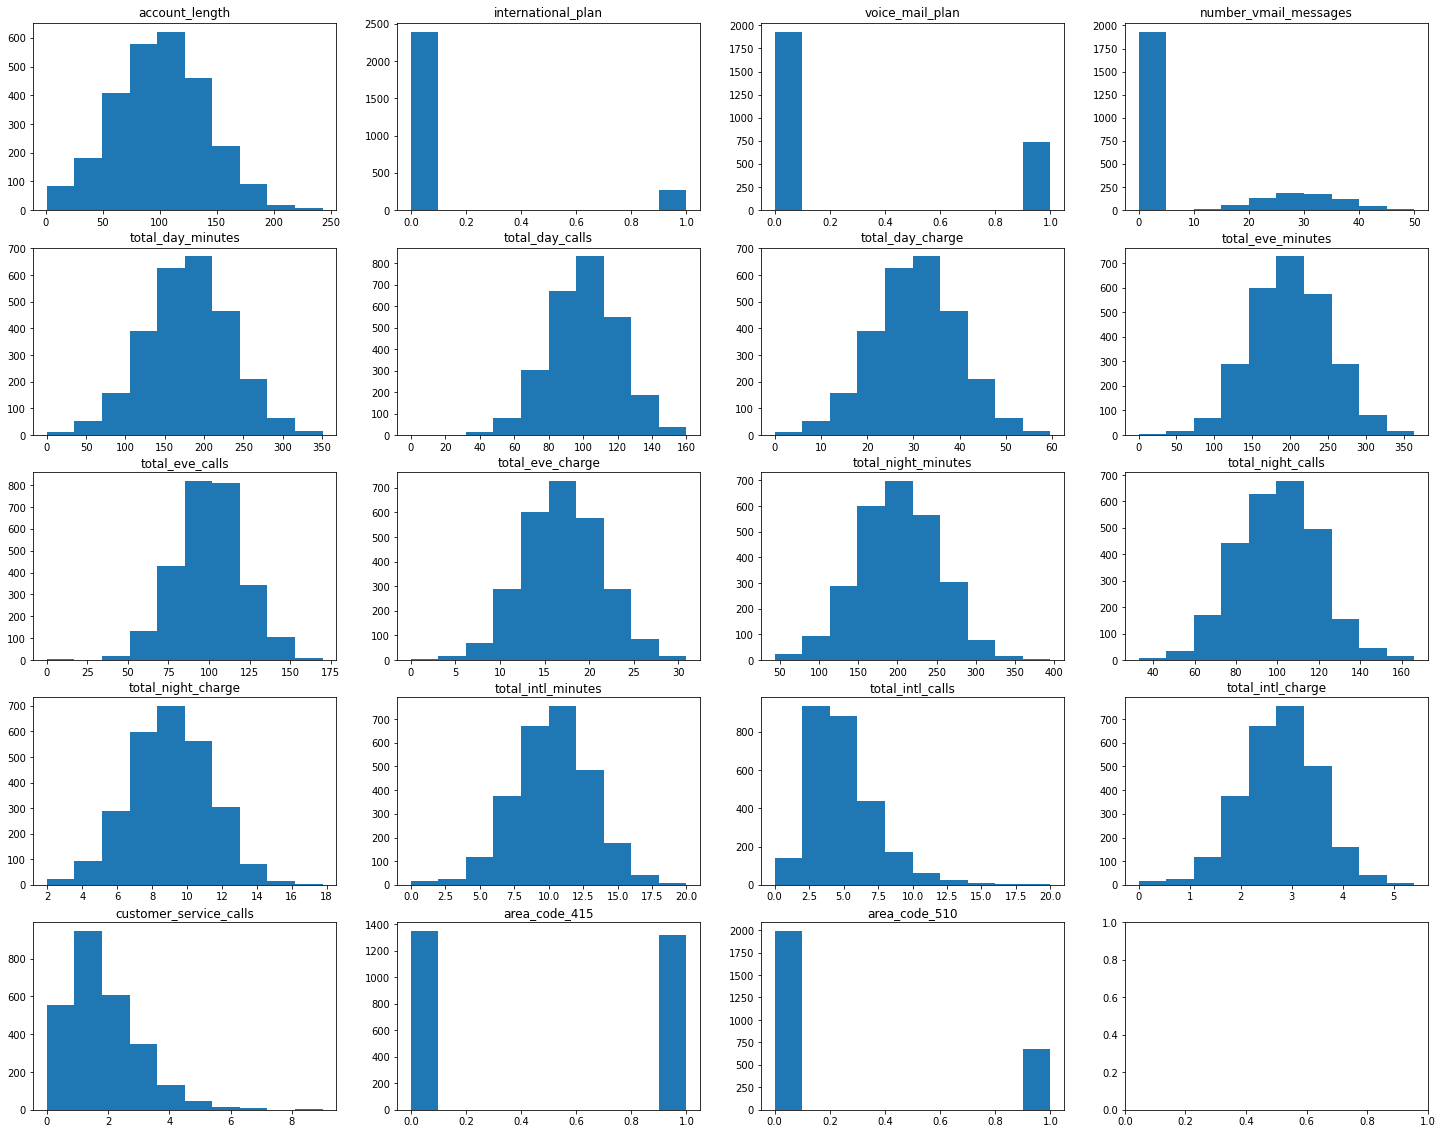

In [138]:
num_row = 4
num_col = 5
fig, ax = plt.subplots(num_col, num_row)
fig.set_figheight(20)
fig.set_figwidth(25)

for index, col in enumerate(X_model.columns):
    if pd.api.types.is_numeric_dtype(X[col]):
        ax[index // num_row, index % num_row].hist(X_model[col])
    else:
        ax[index // num_row, index % num_row].hist(X_model[col])
    ax[index // num_row, index % num_row].set_title(col)

## 6. Evaluation Metrics

In this report, we will use 3 metrics to compare the proformance of our data.

- Accuracy: This is the most common and stright forward one. It tell uses the percentage of the number of correct prediction.

- F1: This metric combind `precision` and `recall`. It is a better indicator to the performance of our model when the output class is imbalance like in our case where the churning is only 17%.

##  7. Naive Baseline Model

First, we create a baseline model by predicting only that the customer will not churn. We could see that the accuracy is pretty high because the number of churning samples are low.

In [139]:
most_occur_class = y_train.value_counts().idxmax()
baseline_predict = np.ones(len(y_val)) * most_occur_class
print(f'Accuracy of Baseline (predict with class {most_occur_class}):', metrics.accuracy_score(y_val, baseline_predict))

Accuracy of Baseline (predict with class False): 0.8576779026217228


## 8. Model#1 Logistic Regression


In [140]:
from sklearn.linear_model import LogisticRegression

### 8.1 Default Model
The default model is used to compare with our final model whether we can improve its performance or not.

In [143]:
default_logistic_regression_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=10000)
score = cross_validate(default_logistic_regression_model, X_train, y_train, cv=5)
print('Mean accuracy of Logistic Regression(default)) cv:', np.mean(score['test_score']))

Mean accuracy of Logistic Regression(default)) cv: 0.8616353860870138


In [144]:
default_logistic_regression_model.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=1234)

### 8.2 Parameter Scaling
First we use various parameter scaling to find out which transformation could deliver the highest cross validation score.

In [145]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=10000))
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=5).fit(X_train, y_train)

We could see that **no scaler** and using `standardScaler()` provide close performance. We picked these two to transform our dataset because we know that scale of parameter could affect the performance of the regularized model

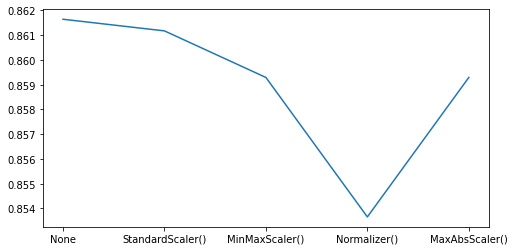

In [147]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 8.3 Tuning Parameter: solver / penalty
Note that we scale the data first with the best method in the previous step.

In [148]:
parameters = [
    {'solver': 'newton-cg', 'penalty': 'l2'},
    {'solver': 'newton-cg', 'penalty': 'none'},
    {'solver': 'lbfgs', 'penalty': 'l2'},
## There is a bug in the implementation so this configuration cannot be run.
#   {'solver': 'lbfgs', 'penalty': 'none'},
    {'solver': 'liblinear', 'penalty': 'l1'},
    {'solver': 'liblinear', 'penalty': 'l2'},
    {'solver': 'sag', 'penalty': 'l2'},
    {'solver': 'sag', 'penalty': 'none'},
    {'solver': 'saga', 'penalty': 'l1'},
    {'solver': 'saga', 'penalty': 'l2'},
    {'solver': 'saga', 'penalty': 'none'}
]

#### 8.3.1 Case 1: Without scaler

In [149]:
accuracy = []

for parameter in parameters:
    pipe = Pipeline([
        ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                          max_iter=10000,
                                          solver=parameter['solver'],
                                          penalty=parameter['penalty']
                                         )
        )
    ])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))

Maximum accuracy for no scaler is 0.8616353860870138
Best model is lbfgs_l2


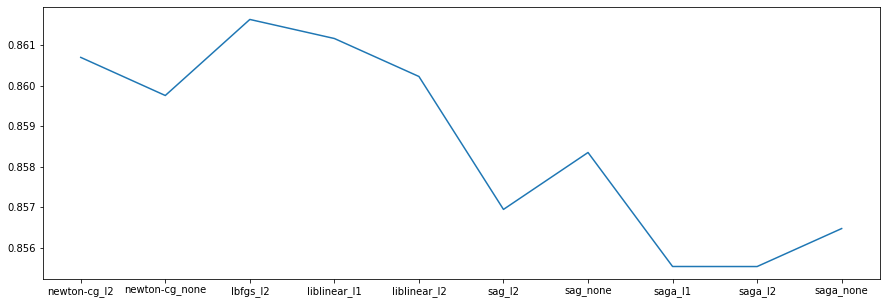

In [150]:
x_ticks = [f'{p["solver"]}_{p["penalty"]}' for p in parameters]
plot_params_accuracy(accuracy, x_ticks, height=5, width=15)
print('Maximum accuracy for no scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

#### 8.3.2 Case 2 with Standard Scaler

In [157]:
accuracy = []

for parameter in parameters:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                          max_iter=10000,
                                          solver=parameter['solver'],
                                          penalty=parameter['penalty']
                                         )
        )
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=5)
    accuracy.append(np.mean(scores['test_score']))

Because there are several model with similar result. We just pick one 'L1' and one for 'L2' penalties. But we learn one thing here that regularization works here as all of the `penalty=none` clearly provide lower performance. 

Maximum accuracy for standard scaler is 0.8611659025189388
Best model is newton-cg_l2


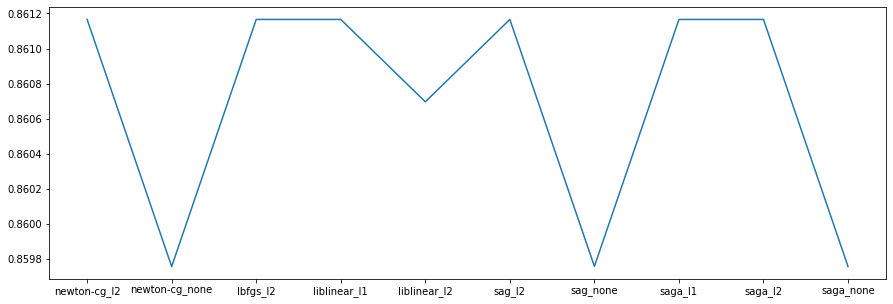

In [158]:
x_ticks = [f'{p["solver"]}_{p["penalty"]}' for p in parameters]
plot_params_accuracy(accuracy, x_ticks, height=5, width=15)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.4 Tuning Parameter: C
C is a regularized parameter. The smaller the more restrict.

In [159]:
C = [0.1, 0.3, 1, 3, 5, 10, 13, 15]

#### For non scaling case

In [178]:
parameters = [
    {'solver': 'lbfgs', 'penalty': 'l2'}
]
accuracy = []
x_ticks = []

for parameter in parameters:
    for regularized_parameter in C:
        pipe = Pipeline([
#             ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                              max_iter=10000,
                                              solver=parameter['solver'],
                                              penalty=parameter['penalty'],
                                              C=regularized_parameter
                                             )
            )
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'{parameter["solver"]}_{parameter["penalty"]}_C={regularized_parameter}')

Maximum accuracy for standard scaler is 0.8625743532231642
Best model is lbfgs_l2_C=0.1


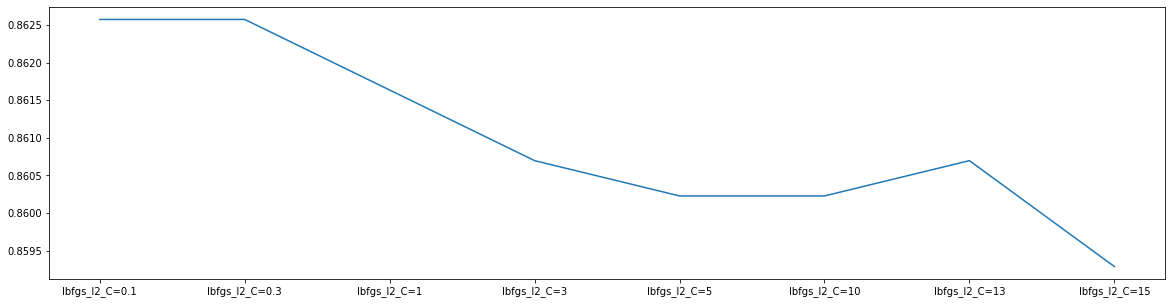

In [179]:
plot_params_accuracy(accuracy, x_ticks, height=5, width=20)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

#### For standard scaling case

In [161]:
parameters = [
    {'solver': 'saga', 'penalty': 'l1'},    
    {'solver': 'newton-cg', 'penalty': 'l2'}
]
accuracy = []
x_ticks = []

for parameter in parameters:
    for regularized_parameter in C:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                              max_iter=10000,
                                              solver=parameter['solver'],
                                              penalty=parameter['penalty'],
                                              C=regularized_parameter
                                             )
            )
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'{parameter["solver"]}_{parameter["penalty"]}_C={regularized_parameter}')

We could see that `solver=newton-cg`,`penalty=l2` and `C=0.3` perform the best.

Maximum accuracy for standard scaler is 0.8616353860870138
Best model is newton-cg_l2_C=0.3


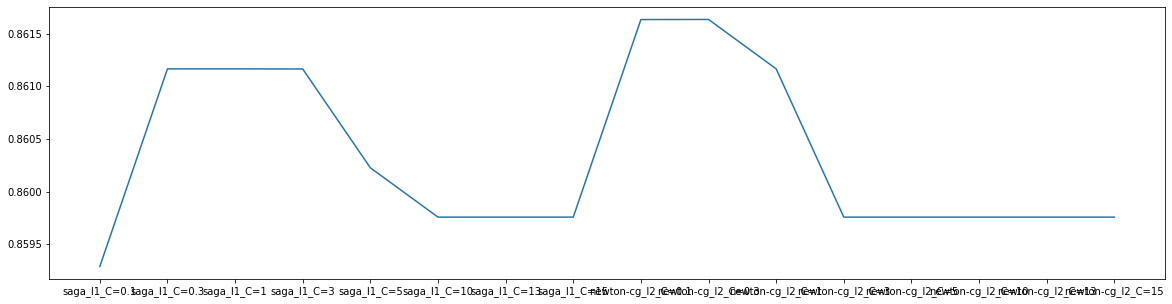

In [162]:
plot_params_accuracy(accuracy, x_ticks, height=5, width=20)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.5 Validation Set

#### 8.5.1 Default Model

In [229]:
default_regression_predict_val = default_logistic_regression_model.predict(X_val)
print('Accuracy of CV training set Logistic Regression(default)):',
      np.mean(cross_validate(default_logistic_regression_model, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set Logistic Regression(default)):',
      metrics.accuracy_score(y_val, default_regression_predict_val))
print('F1 Score of Validation set Logistic Regression(default)):',
      metrics.f1_score(y_val, default_regression_predict_val))

Accuracy of CV training set Logistic Regression(default)): 0.8616353860870138
Accuracy of Validation set Logistic Regression(default)): 0.8614232209737828
F1 Score of Validation set Logistic Regression(default)): 0.2884615384615385


#### 8.5.2 Optimal Model

#### 8.5.2.1 Case 1: No scaler

In [230]:
optimal_logistic_regression_pipe = Pipeline([
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='lbfgs',
                                      penalty='l2',
                                      C=0.1
                                     )
    )
])
scores = cross_validate(optimal_logistic_regression_pipe, X_train, y_train, cv=5)
print('optimal parameter training set score (no scaler) cv:', np.mean(scores['test_score']))
optimal_logistic_regression_pipe.fit(X_train, y_train)
optimal_logistic_regression_predict_val = optimal_logistic_regression_pipe.predict(X_val)
print('optimal parameter set score (no scaler)', metrics.accuracy_score(y_val, optimal_logistic_regression_predict_val))
print('F1 Score of Validation set Logistic Regression (no scaler)):',
      metrics.f1_score(y_val, optimal_logistic_regression_predict_val))

optimal parameter training set score (no scaler) cv: 0.8625743532231642
optimal parameter  set score (no scaler) 0.8651685393258427
F1 Score of Validation set Logistic Regression (no scaler)): 0.2941176470588235


#### 8.5.2.2 Case 2: Standard Scaler

In [231]:
optimal_logistic_regression_standard_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='newton-cg',
                                      penalty='l2',
                                      C=0.3
                                     )
    )
])
scores = cross_validate(optimal_logistic_regression_standard_pipe, X_train, y_train, cv=5)
print('optimal parameter training set score (standard scaler) cv:', np.mean(scores['test_score']))
optimal_logistic_regression_standard_pipe.fit(X_train, y_train)
optimal_logistic_regression_standard_predict_val = optimal_logistic_regression_standard_pipe.predict(X_val)
print('optimal parameter set score (standard scaler)',
      metrics.accuracy_score(y_val, optimal_logistic_regression_standard_predict_val))
print('F1 Score of Validation set Logistic Regression (standard scaler)):',
      metrics.f1_score(y_val, optimal_logistic_regression_standard_predict_val))

optimal parameter training set score (standard scaler) cv: 0.8616353860870138
optimal parameter set score (standard scaler) 0.8614232209737828
F1 Score of Validation set Logistic Regression (standard scaler)): 0.2884615384615385


We could see that our non-scaling case provide the best performace.
Our chosen parameters are `solver='lbfgs'`, `penalty='l2'`, and `C=0.1`

## 9. Model#2 K-Nearest Neighbor

In [184]:
from sklearn.neighbors import KNeighborsClassifier

### 9.1 Default Model

In [185]:
default_knn_classifier = KNeighborsClassifier()
score = cross_validate(default_knn_classifier, X_train, y_train, cv=5)
print('Mean accuracy of K-Nearest Neighbor(default)) cv:', np.mean(score['test_score']))

Mean accuracy of K-Nearest Neighbor(default)) cv: 0.8742971490143043


In [186]:
default_knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

### 9.2 Parameter Scaling

In [187]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', KNeighborsClassifier())
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=5).fit(X_train, y_train)

We see that Standard Scaler and Min Max Scaler data performs at a similar level.

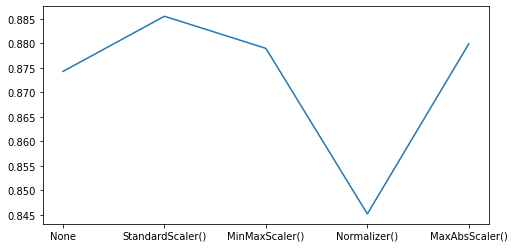

In [188]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 9.3 Tuning Parameter: n_neighbors and p

#### 9.3.1 Case 1: Standard Scaler

In [189]:
p_list = [1, 2, 3]
n_neighbors_lists = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [190]:
accuracy = []
x_ticks = []
for p in p_list:
    for n_neighbors in n_neighbors_lists:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', KNeighborsClassifier(
                p=p,
                n_neighbors=n_neighbors
            ))
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'p={p}_n_neighbors={n_neighbors}')

In [191]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head()

,setting,accuracy
2,p=1_n_neighbors=3,0.890716
4,p=1_n_neighbors=5,0.886031
14,p=2_n_neighbors=5,0.885555
16,p=2_n_neighbors=7,0.885552
24,p=3_n_neighbors=5,0.881799


#### 9.3.2 Case 2: with Min Max Scaler

In [192]:
accuracy = []
x_ticks = []
for p in p_list:
    for n_neighbors in n_neighbors_lists:
        pipe = Pipeline([
            ('scaler', MinMaxScaler()),
            ('classifier', KNeighborsClassifier(
                p=p,
                n_neighbors=n_neighbors
            ))
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'p={p}_n_neighbors={n_neighbors}')

In [193]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head()

,setting,accuracy
2,p=1_n_neighbors=3,0.883207
6,p=1_n_neighbors=7,0.880406
4,p=1_n_neighbors=5,0.880398
14,p=2_n_neighbors=5,0.878996
24,p=3_n_neighbors=5,0.877585


The best parameter set for the standard scaler case is `p=1` and `n_neighbors=1`. While the best parameter set for the min max scaler is `p=3` and `n_neighbors=4`

### 9.4 Validation Set

#### 9.4.1 Default Model

In [227]:
knn_predict_val = default_knn_classifier.predict(X_val)
print('Accuracy of CV training set KNN(default)):',
      np.mean(cross_validate(default_knn_classifier, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set KNN(default)):',
      metrics.accuracy_score(y_val, knn_predict_val))
print('F1 Score of Validation set KNN(default)):',
      metrics.f1_score(y_val, knn_predict_val))

Accuracy of CV training set KNN(default)): 0.8742971490143043
Accuracy of Validation set KNN(default)): 0.8726591760299626
F1 Score of Validation set KNN(default)): 0.3928571428571429


#### 9.4.2 Optimal Model

For standard scaler

In [226]:
stanndard_optimal_knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(
        p=1,
        n_neighbors=3
    ))
])
stanndard_optimal_knn_pipe.fit(X_train, y_train)
scores = cross_validate(stanndard_optimal_knn_pipe, X_train, y_train, cv=5)
print('Optimal parameter training set score KNN (standard scaler):',
      np.mean(scores['test_score'])
)
optimal_knn_pipe_predict_val = stanndard_optimal_knn_pipe.predict(X_val)
print('Optimal parameter set score KNN (standard scaler) validation:',
      metrics.accuracy_score(y_val, optimal_knn_pipe_predict_val)
)
print('F1 Score of Validation set KNN (standard scaler)) validation:',
      metrics.f1_score(y_val, knn_predict_val))

Optimal parameter training set score KNN (standard scaler): 0.8907158799793296
Optimal parameter set score KNN (standard scaler) validation: 0.8838951310861424
F1 Score of Validation set KNN (standard scaler)) validation: 0.3928571428571429


For Min Max Scaler

In [228]:
min_max_optimal_knn_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', KNeighborsClassifier(
        p=1,
        n_neighbors=3
    ))
])
min_max_optimal_knn_pipe.fit(X_train, y_train)
scores = cross_validate(min_max_optimal_knn_pipe, X_train, y_train, cv=5)
print('optimal parameter training set score (min max) cv:', np.mean(scores['test_score']))
optimal_knn_pipe_predict_val = min_max_optimal_knn_pipe.predict(X_val)
print('optimal parameter set score (min max) validation:', metrics.accuracy_score(y_val, optimal_knn_pipe_predict_val))
print('F1 Score of Validation set KNN (standard scaler)) validation:', metrics.f1_score(y_val, optimal_knn_pipe_predict_val))

optimal parameter training set score (min max) cv: 0.8832074413695287
optimal parameter set score (min max) validation: 0.8876404494382022
F1 Score of Validation set KNN (standard scaler)) validation: 0.4545454545454546


The min-max scaler KNN with parameter `p=1` and `n_neighbors=3` performs the best for the validation set.

## 10. Model#3 Random Forest

In [212]:
from sklearn.ensemble import RandomForestClassifier

### 10.1 The default Model

In [232]:
default_random_forest_classifier = RandomForestClassifier(random_state=RANDOM_SEED)
score = cross_validate(default_random_forest_classifier, X_train, y_train, cv=5)
print('Mean accuracy of Random Forest(default)) cv:', np.mean(score['test_score']))
default_random_forest_classifier.fit(X=X_train, y=y_train)

Mean accuracy of Random Forest(default)) cv: 0.9455893832943014


RandomForestClassifier(random_state=1234)

### 10.2 Parameter Scaling

In [214]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', RandomForestClassifier(random_state=RANDOM_SEED))
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=5).fit(X_train, y_train)

We could see that for random forest we might not need any parameter scaling.

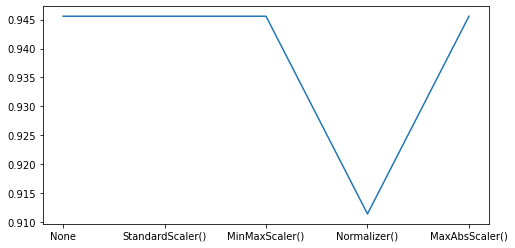

In [215]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 10.3 Tuning Parameter: criterion

In [216]:
accuracy = []
criterion_list = ['entropy', 'gini']
for criteria in criterion_list:
    random_forest_classifier = RandomForestClassifier(criterion=criteria, random_state=RANDOM_SEED)
    random_forest_model = random_forest_classifier.fit(X=X_train, y=y_train)
    predict_val = random_forest_model.predict(X_val)
    accuracy.append(metrics.accuracy_score(y_val, predict_val))

We could see that `entropy` work much better.

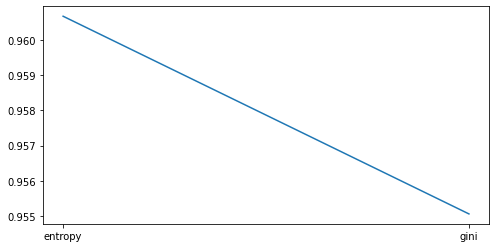

In [217]:
plot_params_accuracy(accuracy, criterion_list, 4, 8)

### 10.4 Tuning Parameter: n_estimators and max_depth

In [218]:
accuracy = []
n_estimator_list = [10, 50, 100, 300, 500, 1000, 3000, 10000]
max_depth_list = [3, 5, 10, 30, 100, 300, None]
x_ticks = []
for n_estimator in n_estimator_list:
    for max_depth in max_depth_list:
        random_forest_classifier = RandomForestClassifier(
            n_estimators=n_estimator, max_depth=max_depth, criterion='entropy', random_state=RANDOM_SEED
        )
        accuracy.append(np.mean(cross_validate(random_forest_classifier, X_train, y_train, cv=5, n_jobs=-1)['test_score']))
        x_ticks.append(f'n_estimator={n_estimator}_max_depth={max_depth}')

We could see that `n_estimator=1000` and `max_depth=100` are the best parameter set.

In [256]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head()

,setting,accuracy
39,n_estimator=1000_max_depth=100,0.944647
40,n_estimator=1000_max_depth=300,0.944647
38,n_estimator=1000_max_depth=30,0.944647
41,n_estimator=1000_max_depth=None,0.944647
16,n_estimator=100_max_depth=10,0.943709


### 10.5 Validation Set

#### 10.5.1 Default Model

In [257]:
default_random_forest_val_predict = default_random_forest_classifier.predict(X_val)
metrics.accuracy_score(y_val, default_random_forest_val_predict)

print('Accuracy of CV training set Random Forest(default)):',
      np.mean(cross_validate(default_random_forest_classifier, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set Random Forest(default)):',
      metrics.accuracy_score(y_val, default_random_forest_val_predict))
print('F1 Score of Validation set Random Forest(default)):',
      metrics.f1_score(y_val, default_random_forest_val_predict))

Accuracy of CV training set Random Forest(default)): 0.9455893832943014
Accuracy of Validation set Random Forest(default)): 0.9550561797752809
F1 Score of Validation set Random Forest(default)): 0.8153846153846153


#### 10.5.2 Optimal Model

In [259]:
optimal_random_forest_classifier = RandomForestClassifier(
    n_estimators=1000, max_depth=100, criterion='entropy', random_state=RANDOM_SEED
)
optimal_random_forest_classifier.fit(X_train, y_train)
optimal_random_forest_val_predict = optimal_random_forest_classifier.predict(X_val)
metrics.accuracy_score(y_val, optimal_random_forest_val_predict)

print('Accuracy of CV training set Random Forest(optimal)):',
      np.mean(cross_validate(optimal_random_forest_classifier, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set Random Forest(optimal)):',
      metrics.accuracy_score(y_val, optimal_random_forest_val_predict))
print('F1 Score of Validation set Random Forest(optimal)):',
      metrics.f1_score(y_val, optimal_random_forest_val_predict))

Accuracy of CV training set Random Forest(optimal)): 0.9446471176787501
Accuracy of Validation set Random Forest(optimal)): 0.9606741573033708
F1 Score of Validation set Random Forest(optimal)): 0.8396946564885496


We found that the optimal forest did a better job at predicting the validation set than the default model.

## Test Set Evaluation

Here we choose a model with the best parameters set from eash machine learning algorithms based on the validation set performance. We retrain the models again with full modelling data and evaluate them with the test set.

### Naive Baseline Model

In [246]:
most_occur_class = y_train.value_counts().idxmax()
baseline_predict_test = np.ones(len(y_test)) * most_occur_class
print(f'Accuracy of Baseline (predict with class {most_occur_class}) test set:',
      metrics.accuracy_score(y_test, baseline_predict_test))
print('F1 Score of Baseline test set:',
      metrics.f1_score(y_test, baseline_predict_test))

Accuracy of Baseline (predict with class False) test set: 0.8575712143928036
F1 Score of Baseline test set: 0.0


### Logistic Regression

In [247]:
final_optimal_logistic_regression_pipe = Pipeline([
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='lbfgs',
                                      penalty='l2',
                                      C=0.1
                                     )
    )
])
final_optimal_logistic_regression_pipe.fit(X_model, y_model)

logistic_regression_predict_test = final_optimal_logistic_regression_pipe.predict(X_test)
print('Accuracy of test set Logistic Regression (optimal)):',
    metrics.accuracy_score(y_test, logistic_regression_predict_test))
print('F1 Score of test set Logistic Regression (optimal)):',
      metrics.f1_score(y_test, logistic_regression_predict_test))

Accuracy of test set Logistic Regression (optimal)): 0.8590704647676162
F1 Score of test set Logistic Regression (optimal)): 0.25396825396825395


### K-Nearest Neighbor

In [248]:
final_min_max_optimal_knn_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', KNeighborsClassifier(
        p=1,
        n_neighbors=3
    ))
])
final_min_max_optimal_knn_pipe.fit(X_model, y_model)


knn_predict_test = final_min_max_optimal_knn_pipe.predict(X_test)


print('Accuracy of test set KNN (optimal)):',
      metrics.accuracy_score(y_test, knn_predict_test))
print('F1 Score of test set KNN (optimal)):',
      metrics.f1_score(y_test, knn_predict_test))

Accuracy of test set KNN (optimal)): 0.8950524737631185
F1 Score of test set KNN (optimal)): 0.5138888888888888


### Random Forest

In [255]:
optimal_random_forest_classifier = RandomForestClassifier(
    n_estimators=1000, max_depth=None, criterion='entropy', random_state=RANDOM_SEED
)
optimal_random_forest_classifier.fit(X_model, y_model)

optimal_random_forest_test_predict = optimal_random_forest_classifier.predict(X_test)
metrics.accuracy_score(y_test, optimal_random_forest_test_predict)
metrics.f1_score(y_test, optimal_random_forest_test_predict)

print('Accuracy of test set Random Forest (optimal)):',
      metrics.accuracy_score(y_test, optimal_random_forest_test_predict))
print('F1 Score of test set Random Forest (optimal)):',
      metrics.f1_score(y_test, optimal_random_forest_test_predict))

Accuracy of test set Random Forest (optimal)): 0.9580209895052474
F1 Score of test set Random Forest (optimal)): 0.8292682926829269


## Summary

We can see that the accuracy of each method aren't differ very much but the F1 score are significantly different. Here we can clearly choose the random forest as a final model.

The final parameter are `criterion='entropy'`, `n_estimator=500` and `max_depth=5`